**在大语言模型（LLM）的强化学习（RL）训练中，损失计算（Loss Computation）的颗粒度是决定训练效果的关键因素。**


你提到的 **Response-level（GRPO）** 和 **Token-level（DAPO）** 正是两种不同演进阶段的损失计算范式。

以下是这两种机制的详细拆解与对比：
## Response-level 损失（GRPO 的机制）
在 GRPO（Group Relative Policy Optimization）中，<font color='red'>损失是基于整个响应序列（Response/Sample）来计算的</font>


### 计算逻辑：
1. 针对同一个 Prompt，模型采样生成一组（Group，共 G 个）完整的回复序列 {$o_1,o_2,...,o_G$} 。
2. 计算每个序列$o_i$内部所有 Token 损失的平均值（即**样本级损失**）。
3. 对这G 个序列的平均损失再取平均值，得到最终的 **Batch Loss**。

### 存在的问题（长序列惩罚不足）：

在长链式思维（Long-CoT）场景中，<font color='red'>样本长度差异巨大</font>。由于 GRPO 是先对单个样本内的 Token 取平均，<font color='blue'>长样本中每个 Token 对总体损失的贡献被严重稀释</font>。这会导致两个负面后果：
  - 学习不足：高质量、包含复杂推理的长样本，其关键 Token 无法获得足够的梯度更新。
  - 惩罚不足：长序列中容易出现的低质量模式（如胡言乱语、重复词语）无法被有效惩罚，导致模型在训练中熵和响应长度出现不健康的增长。
  


## Token-level 损失（DAPO 的机制）

为了解决 GRPO 在长序列上的缺陷，DAPO 提出了 Token 级策略梯度损失（Token-Level Policy Gradient Loss）。
- 计算逻辑：
<font color='red'>DAPO 改变了求平均的顺序</font>。它不再先计算单个序列内部的均值，而是<font color='blue'>将所有样本（Group 内）的所有 Token 的损失直接放在一起求平均。</font>
- 带来的优势（重新平衡梯度）：
  - 公平贡献：<font color='red'>无论生成的序列长短，每一个 Token 对 Batch Loss 的贡献都是绝对公平的，不受序列总长度的影响。</font>
  - 精准奖惩：模型能够更敏锐地捕捉到长序列中的优质推理模式并加以强化；同时，对于过长、无意义的废话 Token，也能给予充分的负面梯度惩罚，从而提升训练的稳定性和最终性能。
  
## 总结
<font color='red'>从 Response-level (GRPO) 到 Token-level (DAPO) 的演进，本质上是对长文本推理（Long-CoT）场景下梯度分布失衡问题的工程修正。</font>
- GRPO 采用“样本级”平均，逻辑简单，**但在长文本场景下容易导致长序列 Token 的学习权重被稀疏化。**
- DAPO 采用“Token级”平均，确保了每一个 Token 都能获得充分的梯度更新信号，使得模型在长序列训练中的熵值和输出长度更加平稳。

(注：除了这两者，业界后来还提出了 GSPO，将重要性采样的颗粒度直接从 Token 级跃升到了 Sequence 级，以解决更底层的分布对齐问题。)

### 代码示例

In [3]:
import torch
import torch.nn.functional as F

class GRPOLossCaculator:
    def __init__(self,epsilon=0.2,beta=0.01):
        """
        Args:
            epsilon:PPO/GRPO的裁剪参数（clip range）
            beta: KL散度惩罚系数
        """
        self.epsilon = epsilon
        self.beta = beta
    
    def compute_response_level_loss(self,log_probs,old_log_probs,rewards,lengths):
        """
        核心函数：计算response-level的GRPO损失
        
        Args:
            log_probs: [batch_size * grpo_size,seq_len] 当前模型的对数概率
            old_log_probs: [batch_size * grpo_size,seq_len] 旧模型（采样时）的对数概率
            rewards: [batch_size * group_size] 每个样本的标量奖励（response-level reward）
            lengths: [batch_size * group_size] 每个样本的实际长度（用于mask）
            
        Returns:
            loss: 最终的标量损失
        """
        # -------------------1.计算importance ratio（重要性比率）-------------------
        # ratio = exp(log_pi_new - log_pi_old)
        # shape: [B * G, seq_len]
        ratio = torch.exp(log_probs - old_log_probs)
        
        #  -------------------2.计算advantage（优势函数）-GRPO的核心-------------------
        # 这里假设rewards已经是针对每个sample的原始奖励
        # 实际GRPO中，通常会在组内对rewards进行归一化：（r - mean）/ std
        # 为了演示response-level逻辑，这里直接使用传入的advantage或归一化后的rewards
        
        #   -------------------关键步骤A： 构造mask（生成动态长度掩码）-------------------
        # 将奖励广播到列表长度维度，并应用掩码
        # shape：【B*G,seq_len】
        '''
        它的核心作用是：在一个固定大小的张量矩阵中，精准地标记出哪些位置是“真实数据”，哪些位置是“无效填充”。
        
        在计算 GRPO 损失时，由于同一个 Batch 中的不同回复序列长度往往不一致，我们需要通过填充让它们的长度对齐。
        但这行代码生成的 mask 就是为了告诉模型：“只计算真实 Token 的损失，忽略那些为了对齐而补上去的 0。”
        
        log_probs.size(1) = 5 (最大序列长度)
        
        逻辑是：如果“当前位置索引” < “该样本总长度”，则为 True，否则为 False。
        '''
        mask = torch.arange(log_probs.size(1),device=log_probs.device).unsqueeze(0) < length.unsqueeze(1)
        
        # 将标量奖励扩展为序列级优势（response-level特征：整条序列共享同一个advantage）
        advantages = rewards.unsqueeze(1).expand_as(log_probs)
        
        # ---关键步骤B：PPO clip目标---
        surr1 = ratios * advantages
        surr2 = torch.clamp(ratios,1.0-self.epsilon,1.0+self.epsilon) * advantages
        
        # 取min得到policy loss（负号是因为我们要最大化目标函数，优化器通常最小化loss）
        policy_loss_per_token = -torch.min(surr1,surr2) * mask.float()
        
        #  -------------------3. response-level 聚合（GRPO的灵魂）-------------------
        # 先对单个序列内的token loss求和，再除以序列长度-》得到在序列的平均loss
        # shape[B*G]
        response_loss = policy_loss_per_token.sum(dim=1) / (lengths.float() + 1e-8)
        
        # 最后对batch内所有样本求平均
        final_policy_loss = response_loss.mean()
        
        return final_policy_loss
    
    def compare_with_token_level(self,log_probs,old_log_probs,rewards,lengths):
        '''
        用于对比：展示DAPO的token-level方法
        '''
        ratios = torch.exp(log_probs - old_log_probs)
        mask = torch.arange(log_probs.size(1),device = log_probs.device).unsqueeze(0) < lengths.unqueeze(1)
        advantages = rewards.unsqueeze(1).expand_as(log_probs)
        
        surr1 = ratios * advantages
        surr2 = torch.clamp(ratios,1.0-self.epsilon,1.0+self.epsilon) * advantages
        
        policy_loss_per_token = -torch.min(surr1,surr2)*mask.float()
        
        # ==========================================================
        # token-level 聚合（DAPO）
        # ==========================================================
        # 直接对所有有效tokenloss求和，除以总token数
        # 不关心这些token属于哪个句子
        
        final_token_loss = policy_loss_per_token.sum() / (mask.float().sum() + 1e-8)
        
        return final_token_loss
    
# ==========================================
# 模拟运行演示
# ==========================================
if __name__ == 'main':
    batch_size = 2 # prompt数量
    group_size = 3 # 每个prompt生成的样本数（group size）
    seq_len = 10   # 最大序列长度
    
    total_samples = batch_size * group_size # 共6个样本
    
    # 模拟数据
    # 随机生成对数概率
    log_probs = torch.randn(total_samples,seq_len)
    old_log_probs = torch.randn(total_samples,seq_len)
    
    # 模拟不同长度的回复
    lengths = torch.tensor([10, 5, 8, 10, 10, 4])
    
    # 模拟奖励：
    # 第2个样本虽然短，但质量高，所以奖励高
    # 第6个样本长，但质量差，奖励低
    rewards = torch.tensor([0.5, 2.0, 0.6, 0.5, 0.5, -1.0]) 
    caculator = GRPOLossCaculator()
    
    # 1.计算grpo（response-level）
    loss_grpo = calculator.compute_response_level_loss(log_probs,old_log_probs,rewards,lengths)
    
    # 2.计算dapo（token-level）
    loss_dapo = calculator.compute_with_token_level(log_probs,old_log_probs,rewards,lenghts)
    
    print(f"GRPO Loss (Response-level): {loss_grpo.item():.4f}")
    print(f"Token-level Loss (DAPO-like): {loss_dapo.item():.4f}")
    

In [ ]:
import torch

# 1. 模拟数据输入
# policy_loss_per_token: [Batch_Size, Seq_Len]
# 这里假设最大长度为 5，样本 A 后面补了 0 (因为有 mask，求和时不影响)
policy_loss_per_token = torch.tensor([
    [0.6, 0.4, 0.2, 0.0, 0.0],  # 样本 A (有效长度 3)
    [1.0, 1.0, 1.0, 1.0, 1.0]   # 样本 B (有效长度 5)
])

# lengths: [Batch_Size]
lengths = torch.tensor([3, 5])

# ---------------------------------------------------------
# 2. 执行代码逻辑：response_loss = sum / lengths
# ---------------------------------------------------------

# 第一步：sum(dim=1) -> 对每个样本内部的所有 Token 损失求和
token_sum = policy_loss_per_token.sum(dim=1)
print(f"样本总损失: {token_sum}") 
# 结果: tensor([1.2000, 5.0000])
# 解释: 样本A总和1.2，样本B总和5.0

# 第二步：lengths.float() + 1e-8 -> 准备分母
# 1e-8 是为了防止除以 0 报错
denominator = lengths.float() + 1e-8
print(f"分母(长度): {denominator}")
# 结果: tensor([3.0000e+00, 5.0000e+00])

# 第三步：相除 -> 得到每个样本的平均损失 (Response-level)
response_loss = token_sum / denominator
print(f"Response-level 损失: {response_loss}")
# 结果: tensor([0.4000, 1.0000])
# 解释: 样本A平均损失 0.4，样本B平均损失 1.0

# ---------------------------------------------------------
# 3. 执行代码逻辑：final_policy_loss = response_loss.mean()
# ---------------------------------------------------------

# 第四步：mean() -> 对 Batch 内所有样本求平均
final_policy_loss = response_loss.mean()
print(f"最终 Batch Loss: {final_policy_loss}")
# 结果: tensor(0.7000)
# 计算过程: (0.4 + 1.0) / 2 = 0.7

In [1]:
from IPython.display import Image

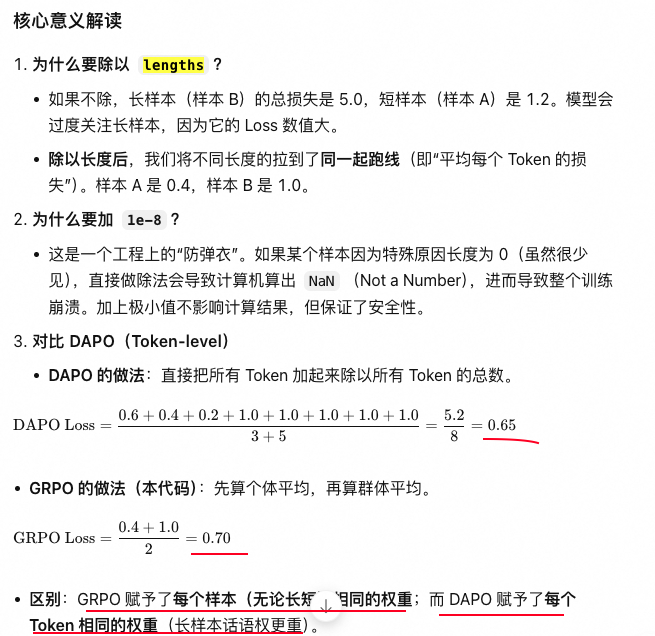

In [4]:
Image(filename='./Image/dapo_vs_grpo.png')

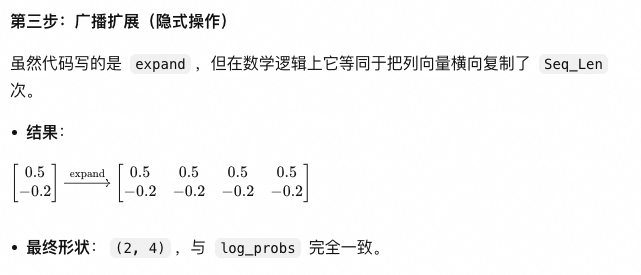

In [2]:
Image(filename='./Image/expand.png')

## 关键细节：expand vs repeat
你可能会问，为什么不直接用 .repeat(1, seq_len)？这里有一个非常重要的显存优化细节：
- repeat：
  - 会在内存中物理复制数据。如果序列很长（比如 2048），它会真的占用 2048 倍的显存来存这个奖励矩阵。
- expand：
  - 不会物理复制数据。它只是创建了一个新的视图，修改了步长。在内存中，它依然只存着 [0.5, -0.2] 这两个数，但在计算时，PyTorch 会假装它们被复制了。

<font color='red'>注意：expand 只能用于大小为 1 的维度。这就是为什么必须先 unsqueeze(1) 把维度变成 1，才能进行 expand。</font>

# GSPO 的 Sequence-level（序列级）重要性采样

- DAPO 和 GSPO 分别代表了强化学习后训练（Post-training）中<font color='red'>两个截然不同、甚至看似“背道而驰”的演进方向。</font>

要理解 GSPO 的 Sequence-level（序列级）重要性采样，我们需要先回顾一下 PPO/GRPO 体系中最基础的“重要性采样（Importance Sampling, IS）”机制，**然后看看 GSPO 是如何对其进行“降维打击”的。**

## 1. 核心矛盾：为什么需要 GSPO？
- 在 PPO 和 GRPO 中，**强化学习的奖励（Reward）是针对整条序列发放的**（即模型生成了一整段话，人类或规则才给一个分数）。
  - <font color='red'>但是，在计算梯度更新时，算法却是在 Token 级别进行重要性采样和裁剪（Clipping）</font>
    - 简单来说，就是“评价是宏观的（针对整句话），但修改是微观的（针对每个词）”

这就导致了一个致命的**粒度错配（Granularity Mismatch）**：
- 单个 Token 级别的重要性采样权重，在长序列中会不断累积，产生极高的方差（训练噪声）。
- <font color='red'>在专家混合模型（MoE）中，由于同一个 Token 在不同阶段可能激活不同的专家，Token 级的概率波动极其剧烈。这种逐 Token 的噪声累积，往往会导致长序列训练时发生灾难性的模型崩溃。</font>

### 核心机制：为什么 MoE 会导致概率波动？
- 在传统的稠密模型（Dense Model，如 LLaMA-3-8B）中，<font color='red'>处理每一个 Token 的都是同一组参数（全量神经网络）。</font>这意味着模型的“性格”是连贯的，对下一个词的概率预测是平滑过渡的。

但在 MoE 模型（如 Mixtral 8x7B, GPT-4）中，情况完全不同：
- 动态路由：
  - <font color='blue'>对于第 t 个 Token，路由器（Router）可能选择了专家 A 和 B；而对于第 t+1 个 Token，路由器可能突然切换到了专家 C 和 D。</font>
- 专家异构性：
  - <font color='red'>不同的专家往往专注于不同的领域</font>（例如专家 A 擅长语法，专家 B 擅长逻辑，专家 C 擅长常识）。
- 结果：
  - **当处理连续的 Token 时，如果负责计算的“大脑区域”频繁切换，模型输出的 Logits（原始分数）和 Probabilities（概率）就会出现剧烈的跳跃。** 这就好比你让一个数学家和一个诗人交替着写一句话，语调和逻辑肯定会忽上忽下。
  
#### 灾难的累积：从“波动”到“崩溃”
文字中提到的“噪声累积”和“灾难性崩溃”是一个连锁反应过程，通常发生在长序列训练中：
- 梯度的不稳定性：
  - 由于概率分布剧烈波动，计算出的损失函数（Loss）也会随之震荡。在反向传播时，这会导致梯度（Gradient）变得极不稳定——一会儿很大，一会儿很小，甚至方向突变。
- 路由器的正反馈陷阱（Routing Collapse）：
  - 这是最致命的一点。MoE 的路由器也是通过梯度学习的。**如果某个 Token 的概率波动导致 Loss 突然变大，路由器可能会错误地认为“刚才选错专家了”**，<font color='red'>从而在下一步极端地调整路由权重。这种调整往往是过激的，导致路由器倾向于把所有 Token 都塞给某一个“看起来安全”的专家，或者在几个专家间疯狂横跳。这就是所谓的模式坍塌。</font>
- 长序列的放大效应：
  - 在短文本中，这种波动可能只是让句子稍微不通顺。但在长序列（如几千个 Token 的代码或文章）生成中，前一步的概率误差会成为后一步的输入。
    - 第 100 步的微小波动 →→ 导致第 101 步选错了专家 →→ 导致第 102 步概率极度自信但错误 →→ ... →→ 第 500 步模型开始输出乱码或重复字符。

#### 什么是“灾难性模型崩溃”？
在 MoE 的语境下，崩溃通常表现为以下几种形式：
- Loss Spike（损失尖峰）：
  - 训练曲线原本平稳，突然垂直上升，且无法恢复。
- Mode Collapse（模式坍塌）：
  - 模型不再输出有意义的内容，而是无限重复某个短语（例如 "The the the..."），或者只输出空白/特殊符号。
- Router Deadlock（路由器死锁）：
  - 路由器彻底放弃使用某些专家，导致模型的有效参数量瞬间减少（例如 8 个专家只用 1 个），模型智力大幅退化。


## 2. GSPO 的核心解法：序列级重要性采样
GSPO（Group Sequence Policy Optimization）的核心思想是：<font color='red'>让优化单元与奖励单元对齐。</font>
  - 既然奖励是针对整个序列的，那么重要性采样和裁剪也必须在序列级别进行。

具体计算流程如下：
### 逐词取对数比：
计算序列中每个 Token 在新旧模型下的对数概率差$log\frac{π_{new}}{π_{old}}$

- 目的：衡量当前策略与旧策略在每个时间步上的“**偏离程度**”。
- 输入：新策略模型输出的对数概率 new_log_probs 和旧策略模型输出的对数概率 old_log_probs。
- 输出：一个形状为 [Batch_Size, Seq_Len] 的张量，每个元素代表对应 Token 的对数概率差。
  
### 序列累加：
将该序列内所有 Token 的对数概率差进行累加（在对数空间下，累加等同于概率空间下的连乘，代表整句似然的变化比）。
  
- 数学意义：在对数空间中，累加等价于概率空间中的连乘，即整个序列的似然比率（Likelihood Ratio）。
- 代码实现：seq_log_ratio = delta_log_probs.sum(dim=1)，结果形状为 [Batch_Size, 1]。
- 关键作用：<font color='red'>将离散的 Token 级变化聚合为一个连续的、代表整句“整体变化”的标量。 </font>

### 长度归一化（关键创新）：
将累加结果除以序列的总长度（Token 数），得到平均每个 Token 的对数变化量。这一步有效抑制了长序列下的权重累积效应。

- 目的：消除序列长度差异带来的方差放大效应。长序列天然有更大的累加值，归一化后使不同长度的序列具有可比性。
- 代码实现：normalized_seq_log_ratio = seq_log_ratio / lengths.float()，其中 lengths 是每个样本的有效长度。
- 重要性：<font color='red'>这是抑制长序列下噪声累积、防止模型崩溃的核心步骤。</font>

### 还原重要性比率：
对归一化后的结果取指数（ exp ），得到最终的序列级重要性比率。

- 含义：**这个比率代表了整个序列在新旧策略下的“平均”概率变化倍数。**
- 代码实现：seq_importance_ratio = torch.exp(normalized_seq_log_ratio)。
- 后续应用：该比率将被用于计算策略损失，并在序列级进行裁剪（Clipping），确保更新幅度可控 

## 3. GSPO vs DAPO：两种截然不同的哲学
虽然 DAPO 和 GSPO <font color='red'>都在试图解决 GRPO 在长序列（Long-CoT）训练中的问题，但它们的切入点完全不同：</font>

| 对比维度 | DAPO (Token-level 思路) | GSPO (Sequence-level 思路) |
| :--- | :--- | :--- |
| 核心目标 | **解决长序列中梯度贡献不均的问题**。 | **解决长序列中重要性采样方差过大导致的训练崩溃**。 |
| 操作对象 | 损失（Loss）的平均化。 | 重要性采样（IS）与裁剪（Clipping）的颗粒度提升。 |
| 具体做法 | **改变求平均的顺序**：<font color='red'>不再先对单个样本内的 Token 取均值，而是把所有样本的所有 Token 放在一起直接求均值。</font> | 将 Token 级的 IS 比率提升为序列级比率，且引入长度归一化。裁剪时直接作用于整个回答。 |
| 物理意义 | 保证长序列中的每一个 Token 都能公平地为 Batch Loss 做贡献，防止长序列的优化梯度被过度缩小。 | <font color='red'>确保“奖励谁，就优化谁，就修正谁”的理论一致性，用整句的平滑信号替代单 Token 的剧烈波动。</font> |
| 适用场景 | 在 3D 生成等任务中，全局结构差异在自回归序列的每一个 token 里都有体现，Token 级优化能更细致感知偏差。 | **在数学推理、代码生成以及 MoE 模型中，序列级信号能显著平摊局部概率波动，提供极稳健的梯度。** |

## 总结
- 简单来说，DAPO 是在微观层面“端平一碗水”，它认为长序列里的每一个 Token 都同等重要，不应该被稀释，所以它把 Loss 的计算颗粒度细化到了 Token 级。

- 而 GSPO 是在宏观层面“看整片森林”，它认为既然奖励是给整段话的，就不应该被单个 Token 的概率剧烈波动带偏，所以它把重要性采样的颗粒度拔高到了 Sequence 级。

<font color='red'>这两者并非绝对互斥，而是针对大模型强化学习中不同痛点（**梯度稀释 vs 方差崩溃**）开出的不同药方。</font>

##  GSPO完整实现代码
GSPO 的核心思想：
  - 将优化单元从 Token 级提升到序列级，通过“**对数空间累加 -> 长度归一化 -> 指数还原**”的流程，计算序列级的 Importance Ratio，从而解决长序列和 MoE 模型中的训练不稳定性。

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GSPO_Loss(nn.Module):
    """
    Group Sequence Policy Optimization (GSPO) Loss 实现
    
    核心逻辑：
    1. 计算 Token 级的对数概率差 (Log Ratios)。
    2. 在序列维度求和，得到整句的 Log Ratio。
    3. 除以序列长度进行归一化 (关键创新)。
    4. 取指数还原为序列级的重要性采样比率 (Sequence-level Ratio)。
    5. 基于该比率计算 PPO 风格的 Clipped Loss。
    """
    
    def __init__(self, clip_epsilon=0.2):
        super().__init__()
        self.clip_epsilon = clip_epsilon

    def forward(self, 
                new_log_probs: torch.Tensor, 
                old_log_probs: torch.Tensor, 
                advantages: torch.Tensor, 
                mask: torch.Tensor, 
                lengths: torch.Tensor):
        """
        Args:
            new_log_probs: [Batch_Size, Seq_Len] 新策略模型输出的对数概率
            old_log_probs: [Batch_Size, Seq_Len] 旧策略模型(Ref)的对数概率
            advantages:    [Batch_Size]           每个样本的奖励/优势值 (Response-level)
            mask:          [Batch_Size, Seq_Len]  有效Token掩码 (1为有效，0为Padding)
            lengths:       [Batch_Size]           每个样本的有效长度 (用于归一化)
            
        Returns:
            loss: 标量，最终的 GSPO Loss
            clip_fraction: 监控指标，被截断的比例
        """
        
        # ---------------------------------------------------------
        # Step 1: 逐词取对数比 (Token-level Log Ratio)
        # 计算新策略与旧策略在每个 Token 上的差异
        # ---------------------------------------------------------
        # delta_log_probs shape: [Batch_Size, Seq_Len]
        delta_log_probs = new_log_probs - old_log_probs
        
        # 应用 Mask：只保留有效 Token 的差异，忽略 Padding
        delta_log_probs = delta_log_probs * mask 

        # ---------------------------------------------------------
        # Step 2: 序列累加 (Sequence Accumulation)
        # 在对数空间累加等价于概率空间的连乘，代表整句的变化幅度
        # ---------------------------------------------------------
        # sum_log_ratio shape: [Batch_Size]
        sum_log_ratio = delta_log_probs.sum(dim=1)

        # ---------------------------------------------------------
        # Step 3: 长度归一化 (Length Normalization - 关键创新)
        # 消除长序列带来的数值累积效应，使不同长度样本可比
        # ---------------------------------------------------------
        # lengths shape: [Batch_Size], 转为 float 防止整数除法
        # normalized_log_ratio shape: [Batch_Size]
        normalized_log_ratio = sum_log_ratio / (lengths.float() + 1e-8)

        # ---------------------------------------------------------
        # Step 4: 还原重要性比率 (Restore Importance Ratio)
        # 将归一化后的对数差还原为线性的序列级比率 r(s)
        # ---------------------------------------------------------
        # ratio shape: [Batch_Size]
        # 注意：这里得到的 ratio 是 "平均每个Token的变化率" 的指数形式
        ratio = torch.exp(normalized_log_ratio)

        # ---------------------------------------------------------
        # Step 5: 计算 PPO Clip Loss
        # 使用序列级比率与序列级 Advantage 进行交互
        # ---------------------------------------------------------
        # advantages shape: [Batch_Size]
        # surr1: 原始重要性采样损失
        surr1 = ratio * advantages
        
        # surr2: 截断后的损失 (限制更新幅度)
        surr2 = torch.clamp(ratio, 1.0 - self.clip_epsilon, 1.0 + self.clip_epsilon) * advantages
        
        # PPO 目标是最小化负收益 (即最大化收益)
        # loss shape: [Batch_Size] -> Scalar
        policy_loss = -torch.min(surr1, surr2).mean()

        # ---------------------------------------------------------
        # 辅助指标：计算有多少样本触发了 Clip (用于监控训练稳定性)
        # ---------------------------------------------------------
        with torch.no_grad():
            clip_frac = ((ratio - 1.0).abs() > self.clip_epsilon).float().mean()

        return policy_loss, clip_frac

### 代码关键点解析

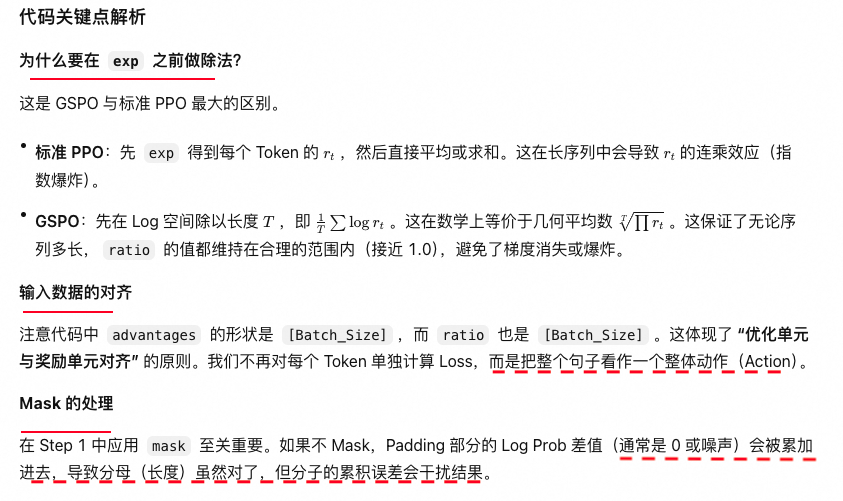

In [7]:
Image(filename='./Image/gspo.png')

### 调用示例

In [ ]:
# 模拟数据
batch_size = 2
seq_len = 5

# 假设这是模型输出的 Log Probs (通常经过 log_softmax)
new_log_probs = torch.randn(batch_size, seq_len) 
old_log_probs = torch.randn(batch_size, seq_len)

# 假设这是 GRPO 计算出的组相对优势
advantages = torch.tensor([1.5, -0.5]) 

# Mask: 样本0有效长度3，样本1有效长度5
mask = torch.tensor([
    [1, 1, 1, 0, 0],
    [1, 1, 1, 1, 1]
], dtype=torch.float32)

lengths = torch.tensor([3, 5])

# 实例化并计算
gspo_loss_fn = GSPO_Loss(clip_epsilon=0.2)
loss, clip_frac = gspo_loss_fn(new_log_probs, old_log_probs, advantages, mask, lengths)

print(f"GSPO Loss: {loss.item():.4f}")
print(f"Clip Fraction: {clip_frac.item():.4f}")

### 将 GSPO 整合进 RLHF 训练循环时，
- 核心在于数据流的组织：
  - 我们需要先生成数据（Rollout），
  - 然后计算奖励（Reward），
  - 最后利用 GSPO 特有的序列级比率进行策略更新。

下面是一个完整的、模块化的 PyTorch 训练循环示例。为了清晰展示 GSPO 的核心逻辑，我将其封装为一个独立的 GSPOTrainer 类。

#### 核心设计思路
1. 生成阶段 (Rollout)：
   - **使用当前策略模型生成回复，并计算旧模型的对数概率**（作为 Importance Sampling 的基准）。
2. 评估阶段 (Evaluation)：
   - 计算新模型的对数概率，并使用 Reward Model 获取序列级奖励。
3. 优势计算 (Advantage)：
   - 在**序列级别计算优势**（例如使用 Group Relative Advantage，即 GRPO 的方式，或者简单的 Baseline）。
4. 更新阶段 (Update)：
   - 这是 GSPO 的关键。<font color='red'>不计算每个 Token 的 Loss，而是先算出整个序列的 Ratio，再计算 Loss。</font>


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from typing import List, Dict, Tuple

# ==========================================
# 1. GSPO 核心算法组件
# ==========================================

class GSPOCriterion(nn.Module):
    """
    GSPO 损失函数计算模块
    特点：优化单元与奖励单元对齐（均为序列级）
    """
    def __init__(self, clip_epsilon: float = 0.2, beta_kl: float = 0.01):
        super().__init__()
        self.clip_epsilon = clip_epsilon
        self.beta_kl = beta_kl

    def forward(self, 
                new_log_probs: torch.Tensor, 
                old_log_probs: torch.Tensor, 
                advantages: torch.Tensor, 
                mask: torch.Tensor,
                ref_log_probs: torch.Tensor = None):
        """
        Args:
            new_log_probs: [B, L] 新策略生成的对数概率
            old_log_probs: [B, L] 旧策略(生成时)的对数概率
            advantages:    [B]   序列级优势值 (已归一化)
            mask:          [B, L] 有效Token掩码 (1为有效)
            ref_log_probs: [B, L] 参考模型对数概率 (用于KL散度，可选)
        """
        # 1. 计算 Token 级对数差
        # [B, L]
        log_diffs = new_log_probs - old_log_probs
        
        # 2. 序列级累加 (Masked Sum)
        # 将无效 padding 
        '''
        log_diffs	[B, T]	每个 token 位置的新旧策略对数概率差：log π_new(y_t) - log π_old(y_t)
        mask	[B, T]	有效 token 为 1，padding 为 0（如 [1,1,1,1,0,0]）
        masked_log_diffs	[B, T]	padding 位置被强制置 0，避免污染求和
        seq_log_ratio	[B]	整条序列的重要性采样比的对数值
        
        log_diffs = [0.2, 0.3, 0.1, -0.1, -999, -999]，最后两个是 padding：
        
        直接求和	0.2+0.3+0.1+(-0.1)+(-999)+(-999) = -1997.5	padding 的虚假值严重扭曲了真实比率
        Mask 后求和	0.2+0.3+0.1+(-0.1) = 0.5	只累加有效 token，结果正确
        '''
        masked_log_diffs = log_diffs * mask
        seq_log_ratio = masked_log_diffs.sum(dim=1)  # [B]
        
        # 3. 长度归一化 (GSPO 关键创新)
        # 防止长序列的 log_ratio 数值过大导致梯度爆炸
        lengths = mask.sum(dim=1).clamp(min=1.0)      # [B]
        normalized_seq_log_ratio = seq_log_ratio / lengths # [B]
        
        # 4. 还原为序列级重要性采样比率
        # 这里得到的 ratio 代表整句话相对于旧策略的变化倍数
        seq_ratio = torch.exp(normalized_seq_log_ratio) # [B]
        
        # 5. 计算 Clipped Loss (PPO 风格)
        # 注意：advantages 是 [B]，ratio 是 [B]，直接逐元素相乘
        surr1 = seq_ratio * advantages
        surr2 = torch.clamp(seq_ratio, 1.0 - self.clip_epsilon, 1.0 + self.clip_epsilon) * advantages
        
        # 取 min 保证单调性，取负号因为我们要最大化奖励(最小化负Loss)
        policy_loss = -torch.min(surr1, surr2).mean()
        
        # 6. (可选) KL 散度惩罚
        # 同样需要在序列级别或 Token 级别进行对齐，这里演示 Token 级 KL 作为正则
        kl_loss = 0.0
        if ref_log_probs is not None:
            # KL = sum( (p_new - p_ref) * ... ) 近似计算
            kl = (new_log_probs - ref_log_probs).exp() - (new_log_probs - ref_log_probs) - 1.0
            kl_loss = (kl * mask).sum(dim=1).mean()
            
        total_loss = policy_loss + self.beta_kl * kl_loss
        
        return total_loss, policy_loss, kl_loss, seq_ratio.detach().mean()


# ==========================================
# 2. 模拟环境与模型 (用于演示)
# ==========================================

class DummyModel(nn.Module):
    """模拟 LLM"""
    def __init__(self, vocab_size=1000, hidden_size=64):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, hidden_size)
        self.lm_head = nn.Linear(hidden_size, vocab_size)
    
    def forward(self, input_ids):
        hidden = self.embed(input_ids)
        logits = self.lm_head(hidden)
        return logits
    
    def get_log_probs(self, input_ids, labels):
        """获取指定 labels 的对数概率"""
        logits = self.forward(input_ids)
        log_probs = F.log_softmax(logits, dim=-1)
        # Gather 对应 label 的概率
        token_log_probs = log_probs.gather(-1, labels.unsqueeze(-1)).squeeze(-1)
        return token_log_probs

class DummyRewardModel:
    """模拟 Reward Model"""
    def __init__(self):
        pass
    
    def get_reward(self, sequences):
        # 简单模拟：序列越长奖励越高，加一点随机噪声
        lengths = (sequences != 0).sum(dim=1).float()
        rewards = lengths * 0.5 + torch.randn_like(lengths) * 0.1
        return rewards


# ==========================================
# 3. RLHF 训练循环集成
# ==========================================

class RLHF_GSPO_Trainer:
    def __init__(self, config):
        self.config = config
        self.policy_model = DummyModel(config['vocab_size']).to(config['device'])
        self.ref_model = DummyModel(config['vocab_size']).to(config['device'])
        self.reward_model = DummyRewardModel()
        
        # 冻结 Reference Model
        for param in self.ref_model.parameters():
            param.requires_grad = False
            
        self.optimizer = torch.optim.AdamW(self.policy_model.parameters(), lr=config['lr'])
        self.gspo_criterion = GSPOCriterion(clip_epsilon=config['clip_eps'])
        
    @torch.no_grad()
    def generate_rollouts(self, prompts):
        """
        第一阶段：生成数据
        使用当前 Policy Model 生成回复，并记录 Old Log Probs
        """
        self.policy_model.eval()
        
        batch_size = len(prompts)
        max_len = self.config['max_gen_len']
        
        # 简化版生成逻辑 (实际应使用 generate 函数)
        # 这里假设 prompts 已经是 tensor [B, Prompt_Len]
        # 生成的 sequences 是 [B, Total_Len]
        generated_seqs = prompts.clone() 
        
        # 模拟生成过程... (省略具体 decoding 循环)
        # 假设我们生成了随机 tokens 拼接在后面
        random_tokens = torch.randint(10, 50, (batch_size, max_len), device=self.config['device'])
        generated_seqs = torch.cat([prompts, random_tokens], dim=1)
        
        # 计算 Old Log Probs (基于生成时的模型状态)
        # 注意：实际工程中通常只计算 Response 部分的 log probs
        old_log_probs = self.policy_model.get_log_probs(generated_seqs, generated_seqs)
        
        # 获取 Reward
        rewards = self.reward_model.get_reward(generated_seqs)
        
        # 构建 Mask (假设 prompt 部分不参与 RL 优化，或者全参与)
        # 这里简单处理：非 padding (0) 即为有效
        mask = (generated_seqs != 0).float()
        
        return {
            'sequences': generated_seqs,
            'old_log_probs': old_log_probs,
            'rewards': rewards,
            'mask': mask
        }

    def compute_group_advantages(self, rewards, prompts):
        """
        计算组相对优势 (Group Relative Advantage)
        这是 GRPO/GSPO 常用的技巧：同一 Prompt 生成 N 个回答，互相比较
        """
        # 假设输入是按 Prompt 分组的
        # 这里简化为全局归一化 (Global Normalization)
        mean_r = rewards.mean()
        std_r = rewards.std() + 1e-8
        advantages = (rewards - mean_r) / std_r
        return advantages

    def train_step(self, batch_data):
        """
        第二阶段：策略更新
        """
        self.policy_model.train()
        
        sequences = batch_data['sequences']
        old_log_probs = batch_data['old_log_probs']
        rewards = batch_data['rewards']
        mask = batch_data['mask']
        
        # 1. 计算 Advantages
        advantages = self.compute_group_advantages(rewards, None)
        
        # 2. 计算 New Log Probs
        # 需要重新前向传播一次
        new_log_probs = self.policy_model.get_log_probs(sequences, sequences)
        
        # 3. 计算 Reference Log Probs (可选，用于 KL)
        with torch.no_grad():
            ref_log_probs = self.ref_model.get_log_probs(sequences, sequences)
            
        # 4. 计算 GSPO Loss
        loss, p_loss, k_loss, ratio = self.gspo_criterion(
            new_log_probs=new_log_probs,
            old_log_probs=old_log_probs,
            advantages=advantages,
            mask=mask,
            ref_log_probs=ref_log_probs
        )
        
        # 5. 反向传播
        self.optimizer.zero_grad()
        loss.backward()
        # 梯度裁剪 (Clip Gradient) 对于 RL 很重要
        '''
        这段代码是 RL 训练中梯度裁剪（Gradient Clipping）的标准写法。它在调用优化器更新权重之前，对策略模型的梯度进行"封顶"处理。
        
        clip_grad_norm_(..., max_norm=1.0)	限制梯度的 L2 范数不超过 1.0	如果所有参数的梯度合起来的范数 > 1.0，就按比例缩放，使其恰好等于 1.0
        
        注意 clip_grad_norm_ 末尾的下划线 _，表示这是in-place 操作，直接修改参数的 .grad 属性，不返回新张量。
        '''
        torch.nn.utils.clip_grad_norm_(self.policy_model.parameters(), max_norm=1.0)
        self.optimizer.step()
        
        return {
            'loss': loss.item(),
            'policy_loss': p_loss.item(),
            'kl_loss': k_loss.item(),
            'avg_ratio': ratio.item(),
            'avg_reward': rewards.mean().item()
        }

    def train_loop(self, dataloader, epochs=3):
        """完整训练流程"""
        for epoch in range(epochs):
            print(f"--- Epoch {epoch+1} ---")
            for step, prompts in enumerate(dataloader):
                prompts = prompts.to(self.config['device'])
                
                # A. Rollout & Reward
                batch_data = self.generate_rollouts(prompts)
                
                # B. Update Policy
                metrics = self.train_step(batch_data)
                
                if step % 10 == 0:
                    print(f"Step {step}: "
                          f"Loss={metrics['loss']:.4f} | "
                          f"Reward={metrics['avg_reward']:.4f} | "
                          f"Ratio={metrics['avg_ratio']:.4f}")


# ==========================================
# 4. 运行示例
# ==========================================

if __name__ == "__main__":
    # 配置参数
    config = {
        'vocab_size': 1000,
        'device': 'cpu',  # 如果有 GPU 改为 'cuda'
        'lr': 1e-5,
        'max_gen_len': 20,
        'clip_eps': 0.2
    }
    
    # 初始化 Trainer
    trainer = RLHF_GSPO_Trainer(config)
    
    # 构造虚拟 Dataloader (Batch of Prompts)
    dummy_prompts = torch.randint(1, 100, (4, 10)).to(config['device']) # 4个样本，长度10
    dataset = [dummy_prompts] * 50 # 模拟 50 个 batch
    loader = DataLoader(dataset, batch_size=None) # 这里的 batch_size=None 是因为数据本身已经是 batch
    
    # 开始训练
    trainer.train_loop(loader, epochs=1)

#### 代码关键点解析

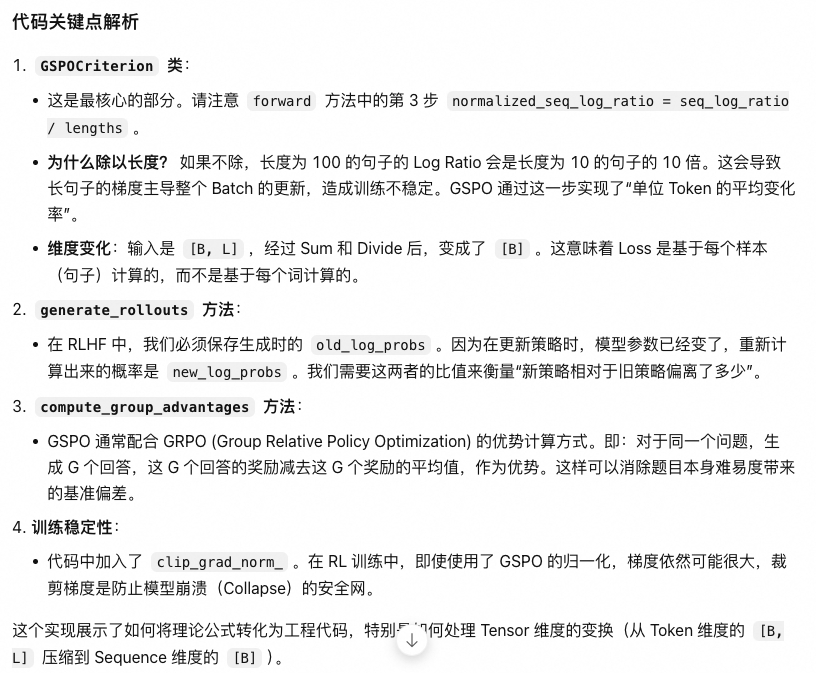

In [6]:
Image(filename='./Image/gspo_c.png')